In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

TASK 1 ~ Data Loading & Exploration

In [3]:
#To load the dataset
HousePrice_data = pd.read_csv("C:\\Datasets\\Housing _Prices\\Housing.csv")

In [4]:
#To display the first 10 rows
HousePrice_data.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [5]:
#To check the number of rows and columns (rows, columns)
HousePrice_data.shape

(545, 13)

In [6]:
# To check the number of rows and columns respectively
print("Total numbers of rows in the dataset: ", HousePrice_data.shape[0])
print("Total numbers of columns in the dataset: ", HousePrice_data.shape[1])

Total numbers of rows in the dataset:  545
Total numbers of columns in the dataset:  13


In [7]:
#To list all columns: Price(Target) and the rest(Features)
HousePrice_data.columns.tolist()

['price',
 'area',
 'bedrooms',
 'bathrooms',
 'stories',
 'mainroad',
 'guestroom',
 'basement',
 'hotwaterheating',
 'airconditioning',
 'parking',
 'prefarea',
 'furnishingstatus']

(Target) -->  price
(Numerical Features) --> area, bedrooms, bathrooms, stories,  parking
(Binary Features) --> mainroad, guestroom, basement, hotwaterheating, airconditioning, prefarea
(Categorical Features)--> furnishingstatus

In [9]:
HousePrice_data.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

TASK 2 ~ Data Cleaning

No missing values. Otherwise, to drop the row --> HousePrice_data.dropna()

In [12]:
#To check the number of duplicates 
HousePrice_data.duplicated().sum()

#To remove duplicates --> HousePrice_data.drop_duplicates(inplace=True)

0

In [13]:
# To convert categorical columns into numeric form (One-Hot Encoding)
categorical_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']

HousePrice_data = pd.get_dummies(HousePrice_data,columns=categorical_cols, drop_first=True, dtype=int)

In [14]:
HousePrice_data.columns.tolist()

['price',
 'area',
 'bedrooms',
 'bathrooms',
 'stories',
 'parking',
 'mainroad_yes',
 'guestroom_yes',
 'basement_yes',
 'hotwaterheating_yes',
 'airconditioning_yes',
 'prefarea_yes',
 'furnishingstatus_semi-furnished',
 'furnishingstatus_unfurnished']

Every column is needed this assignment. If not, HousePrice_data.drop(columns=['column_name'], inplace=True)

In [16]:
HousePrice_data.head(10)

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,1,0,0,0,1,1,0,0
1,12250000,8960,4,4,4,3,1,0,0,0,1,0,0,0
2,12250000,9960,3,2,2,2,1,0,1,0,0,1,1,0
3,12215000,7500,4,2,2,3,1,0,1,0,1,1,0,0
4,11410000,7420,4,1,2,2,1,1,1,0,1,0,0,0
5,10850000,7500,3,3,1,2,1,0,1,0,1,1,1,0
6,10150000,8580,4,3,4,2,1,0,0,0,1,1,1,0
7,10150000,16200,5,3,2,0,1,0,0,0,0,0,0,1
8,9870000,8100,4,1,2,2,1,1,1,0,1,1,0,0
9,9800000,5750,3,2,4,1,1,1,0,0,1,1,0,1


TASK 3 ~ Model Building

In [18]:
#To split the data

from sklearn.model_selection import train_test_split

# x is features, y is the target
x = HousePrice_data.drop(columns=['price'])
y = HousePrice_data['price']

#20% = testing, 80%  = training
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [19]:
#Linear_Regression
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(x_train, y_train)
y_pred_lr = lr_model.predict(x_test)

In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2 = r2_score(y_test, y_pred_lr)

print(f"MAE  : {mae:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"R²   : {r2:.4f}")

MAE  : 970,043.40
RMSE : 1,324,506.96
R²   : 0.6529


In [21]:
#Random Forest, n_estimators=100 means 100 decision trees
# More trees = more stable but slower

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(x_train, y_train)
y_pred_rf = rf_model.predict(x_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(f"MAE  : {mae_rf:,.2f}")
print(f"RMSE : {rmse_rf:,.2f}")
print(f"R²   : {r2_rf:.4f}")

MAE  : 1,021,546.04
RMSE : 1,400,565.97
R²   : 0.6119


In [22]:
print(f"{'Metric':<10}|{'Linear Regression':>20} | {'Random Forest':>20}")
print("-" * 52)
print(f"{'MAE':<10}|{mae:>20,.2f} |{mae_rf:>20,.2f}")
print(f"{'RMSE':<10}|{rmse:>20,.2f} |{rmse_rf:>20,.2f}")
print(f"{'R²':<10}|{r2:>20.4f} |{r2_rf:>20.4f}")

Metric    |   Linear Regression |        Random Forest
----------------------------------------------------
MAE       |          970,043.40 |        1,021,546.04
RMSE      |        1,324,506.96 |        1,400,565.97
R²        |              0.6529 |              0.6119


TASK 4 ~ Visualization

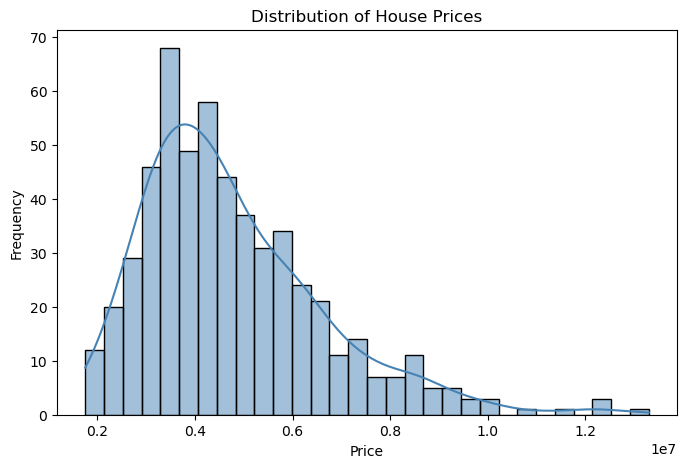

In [24]:
#Distribution of House Prices

plt.figure(figsize=(8, 5))
sns.histplot(HousePrice_data['price'], bins=30, kde=True, color='steelblue')
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

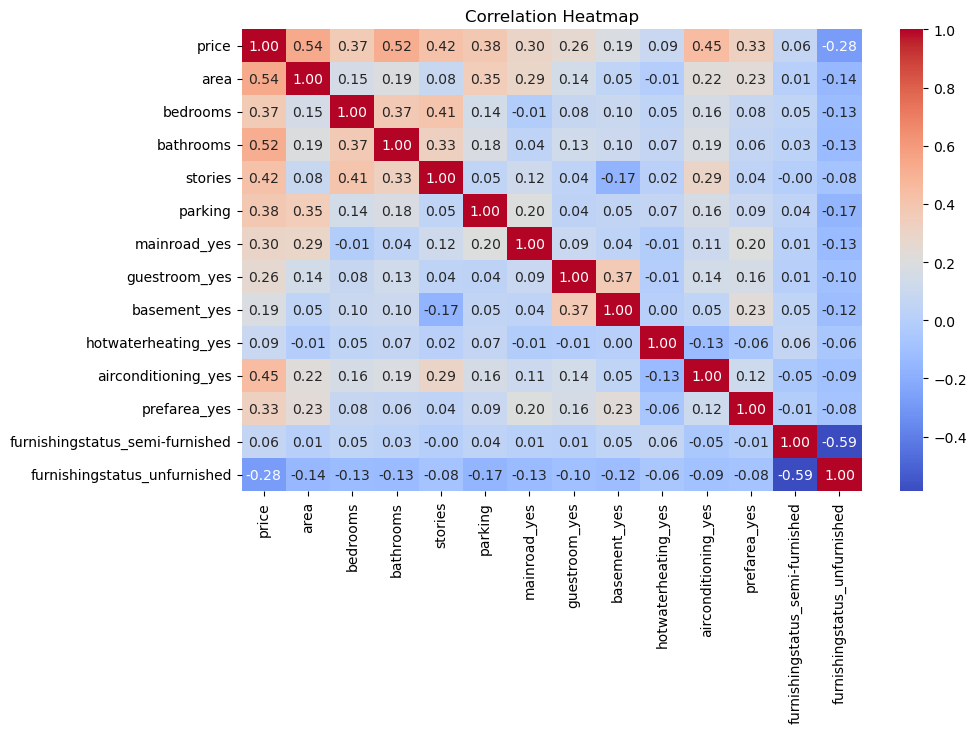

In [45]:
plt.figure(figsize=(10, 6))
sns.heatmap(HousePrice_data.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

Insights on the above Correlation Heatmap:

Features             Correlation    Relation with House Price
---------            ------------   ---------------------------
area                 0.54          bigger area, higher price
bathrooms            0.52          more bathrooms, higher price
airconditioning_yes  0.45          more AC installed, higher price
furnishingstatus_    -0.28         Unfurnished places, lower price
unfurnished
hotwaterheating_     0.09          Barely matters
yes

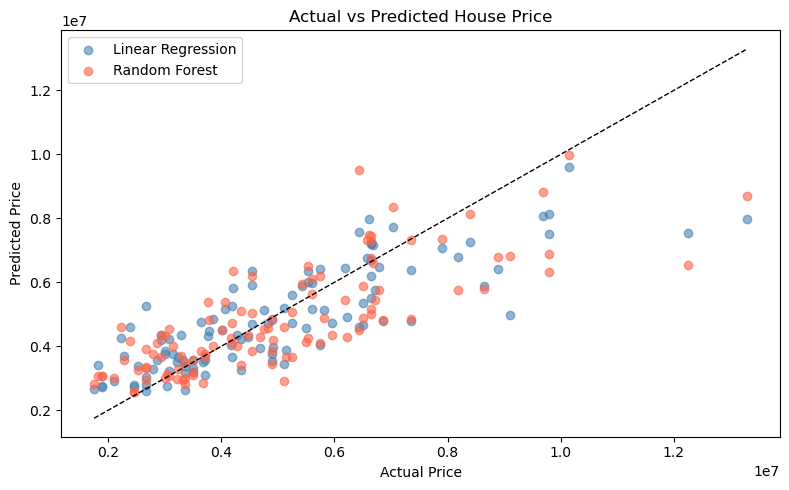

In [48]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred_lr, alpha=0.6, color='steelblue', label='Linear Regression')
plt.scatter(y_test, y_pred_rf, alpha=0.6, color='tomato', label='Random Forest')

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', linewidth=1)

plt.title('Actual vs Predicted House Price')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.legend()
plt.tight_layout()
plt.show()

Insights on the above ScatterPlot

~ Both models perform reasonably well in prediction of lower-priced houses.
~ Both models underpredicts higher-priced houses because data of high-value houses are rare in this dataset.
~ Linear Regression shows more consistent spread
~ Random Forest has a few noticeable outliers


TASK 5 ~ Insights & Summary

Query 1 :  Which features influence house price the most?
Area, bathrooms and airconditioning with correlation values of 0.54, 0.52, and 0.45 respectively influence house prices the most.

Query 2 : How accurate is the model?
Linear Regression model was correct about 65% of the time in explaining 
price differences between houses.On average, its predictions were off by around 970,000. Not perfect but reasonably well for this amount of small dataset.

Query 3 : What surprised me in the data?
~ Hot water heating had almost no impact on the price  despite being a household facility.
~ Random Forest being outperformed by Linear Regression ( likely due to the small dataset size probably causing overfitting). 

Query 4 : Recommendations
~ Facilities over Rooms
Airconditioning (0.45) correlates with price more strongly than bedrooms (0.37). This suggests buyers value comfort features over raw room count.
~ Bathrooms (0.52) correlate more strongly with price than bedrooms (0.37), meaning more bathrooms, higher price. However, it raises a practical concern because a house with more bathrooms than bedrooms would be unrealistic.
~ Furnishing has asymmetric impact
Unfurnished status hurts price (-0.28) more noticeably than semi-furnished status (0.06). So the biggest decision is furnished vs unfurnished because going semi-furnished barely makes a difference.
